# 03. Desirability 최적화 → 2차 DOE → 검증 → SPC

## Derringer–Suich Desirability Function (1980)

각 반응 y를 만족도 d ∈ [0, 1]로 변환한 뒤 기하평균으로 종합 만족도 D를 만든다:

- **ER (클수록 좋음)**: d = (y − 280) / (380 − 280), [0,1] 클리핑
- **U/T, M/D (작을수록 좋음)**: d = (상한 − y) / (상한 − 하한)
- **θ (목표값 90°)**: 90°에서 d=1, ±3° 밖에서 d=0인 삼각형
- **종합**: D = (d_ER · d_UT · d_MD · d_θ)^(1/4) — 하나라도 0이면 D=0

기하평균을 쓰는 이유: 어떤 반응 하나가 완전히 불만족(d=0)인 레시피는
다른 반응이 아무리 좋아도 탈락시켜야 하기 때문이다.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import RANDOM_SEED, SECOND_DOE_CHF3, TRUE_COEF, SPECS
from src.data_gen import simulate_experiment, simulate_replicates
from src.doe_design import first_doe, second_doe
from src.analysis import (fit_all, fit_ols, ols_report, predict,
                          standardized_effects)
from src.optimization import (best_condition, desirability, grid_search,
                              validation_table)
from src.spc import monitoring_run, reproducibility_report
from src.visualization import (desirability_contour, effect_magnitude_plot,
                               i_chart_panel, main_effects_plot,
                               tradeoff_plot)

pd.set_option("display.width", 120)


1차 모델 기준 최적점: P=15.0 mTorr, B=78.0 W, D=0.554


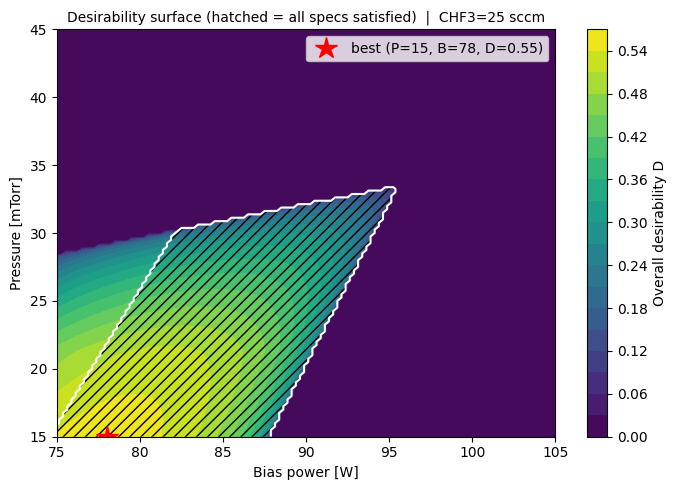

In [2]:
doe1 = simulate_experiment(first_doe(), seed=RANDOM_SEED)
models = fit_all(doe1, ["ER", "UT", "MD", "THETA"])

# 1차 DOE 결론에 따라 CHF3는 중앙값 25 sccm에 고정 (효과가 가장 작은 보조 인자)
grid1 = grid_search(models, fixed={"CHF3": SECOND_DOE_CHF3}, n_grid=121)
best1 = best_condition(grid1)
print(f"1차 모델 기준 최적점: P={best1['P']:.1f} mTorr, B={best1['B']:.1f} W, D={best1['D']:.3f}")
fig = desirability_contour(grid1, best1, fixed_label=f"CHF3={SECOND_DOE_CHF3:g} sccm")
plt.show()

빗금 영역이 **4개 스펙을 모두 만족하는 feasible region**이다.
저압(P≈15)·중간 Bias(B≈75~85) 코너에 최적점이 있다 —
저압은 U/T와 θ를 살리고, Bias는 ER(≥300)과 M/D(≤3)의 타협점을 찾은 결과다.

## 2차 DOE — 최적점 주변 정밀 탐색

1차 최적점이 탐색 범위 경계(P=15) 근처라서, CHF₃=25 고정 후
**Pressure 15~25 mTorr / Bias 60~90 W** 좁은 창에서 3×3 = 9 runs를 추가로 돌린다.
(Bias는 하한을 75 → 60 W까지 내려 경계 바깥도 확인)

In [3]:
doe2 = simulate_experiment(second_doe(), seed=RANDOM_SEED + 1)
doe2

,run,CHF3,P,B,ER,UT,MD,THETA
0,1,25.0,15.0,60.0,264.221,1.323,0.000,90.761
1,2,25.0,15.0,75.0,303.891,0.994,1.397,90.751
2,3,25.0,15.0,90.0,335.072,0.588,3.481,90.442
3,4,25.0,20.0,60.0,252.457,1.544,0.000,90.283
4,5,25.0,20.0,75.0,284.541,1.264,0.965,90.259
5,6,25.0,20.0,90.0,336.858,0.920,3.055,90.024
6,7,25.0,25.0,60.0,251.083,2.003,0.000,89.937
7,8,25.0,25.0,75.0,289.529,1.638,0.990,89.466
8,9,25.0,25.0,90.0,322.082,1.459,2.897,89.398


최종 레시피: CHF3=25 sccm / P=15 mTorr / B=79 W


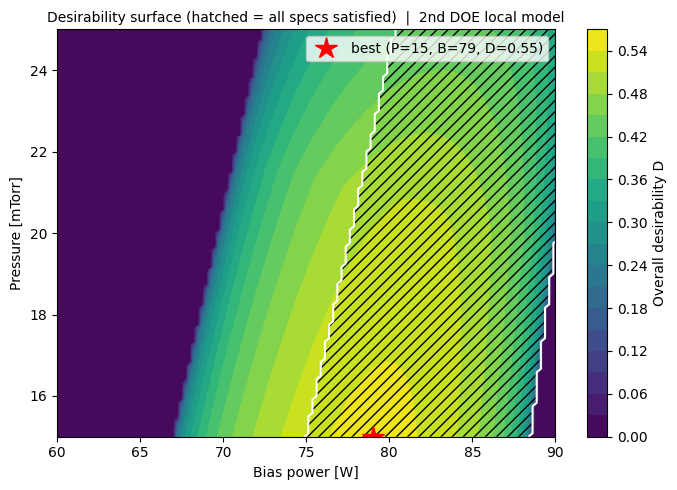

In [4]:
models2 = fit_all(doe2, ["ER", "UT", "MD", "THETA"])
grid2 = grid_search(models2, ranges={"P": (15.0, 25.0), "B": (60.0, 90.0)},
                    fixed={"CHF3": SECOND_DOE_CHF3}, n_grid=121)
best2 = best_condition(grid2)
final = {"CHF3": SECOND_DOE_CHF3, "P": round(best2["P"]), "B": round(best2["B"])}
print(f"최종 레시피: CHF3={final['CHF3']:g} sccm / P={final['P']:g} mTorr / B={final['B']:g} W")
fig = desirability_contour(grid2, best2, fixed_label="2nd DOE local model")
plt.show()

## 최종 레시피 검증 — 회귀식 대입 PASS/FAIL

1차 DOE의 글로벌 모델에 최종 조건을 대입해 스펙 충족 여부를 판정한다.

In [5]:
pred = predict(models, final)
validation_table(pred)

,response,predicted,criterion,result
0,ER,311.22,>= 300.0,PASS
1,UT,0.88,<= 2.0,PASS
2,MD,1.96,<= 3.0,PASS
3,THETA,90.70,90.0 +/- 3.0,PASS


## 재현성 확인 — 반복 run (n=3)

같은 레시피로 3회 반복 시뮬레이션하여 산포(σ)와
회귀 예측값 ±3σ_noise 밴드 내 포함 여부를 확인한다.

In [6]:
reproducibility_report(final, pred, n=3, seed=RANDOM_SEED + 2)

,response,predicted,mean,sigma,band,all_within_band
0,ER,311.22,313.625,3.599,+/- 15,True
1,UT,0.88,0.905,0.028,+/- 0.3,True
2,MD,1.96,1.879,0.105,+/- 0.45,True
3,THETA,90.70,90.776,0.101,+/- 0.45,True


## SPC 확장 — 양산 관리도 (I-chart)

레시피 확정 후에는 관리도로 공정 드리프트를 조기에 감지한다.
25개 lot을 시뮬레이션하고 개별값 관리도(I-chart)의 UCL/LCL(= CL ± 2.66·MR̄)을 그린다.

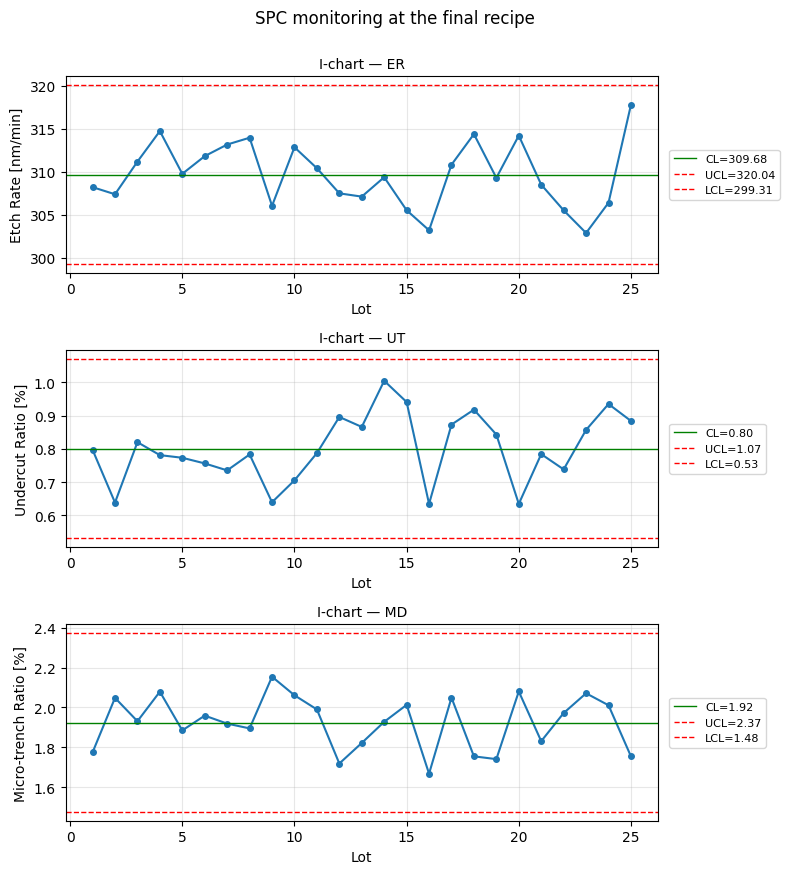

In [7]:
lots = monitoring_run(final, n_lots=25, seed=RANDOM_SEED + 3)
fig = i_chart_panel(lots, ["ER", "UT", "MD"])
plt.show()

## 최종 결론

| 항목 | 값 |
|---|---|
| **최종 레시피** | CHF₃ 25 sccm / Pressure 15 mTorr / Bias ≈ 79 W |
| ER | ≈ 311 nm/min (≥ 300 **PASS**) |
| U/T | ≈ 0.9 % (≤ 2.0 **PASS**) |
| M/D | ≈ 2.0 % (≤ 3.0 **PASS**) |
| θ | ≈ 90.7° (90 ± 3 **PASS**) |

**총 실험 횟수 36 runs** (27 + 9)로 4개 반응을 동시에 만족하는 조건을 찾았다.
OFAT로 같은 해상도를 얻으려면 인자당 별도 스윕이 필요해 실험 수가 크게 늘고,
인자 간 상충 구조(Bias의 ER↔M/D)는 아예 발견하지 못했을 것이다.

### 한계점
- 모든 데이터는 **1차 선형 ground truth 기반 시뮬레이션**이다. 실제 식각 공정은
  강한 비선형·교호작용(예: polymer 과다 시 etch stop)이 존재한다.
- 노이즈를 i.i.d. 가우시안으로 가정 — 실제 장비는 드리프트/lot 간 상관이 있다.
- 실무에서는 SEM 계측 오차, 챔버 상태(PM 주기) 등이 추가 변수가 된다.